# t-SNE

t-SNE stands for:

**t-Distributed Stochastic Neighbor Embedding**

t-SNE is an **unsupervised dimensionality reduction technique** mainly used for visualizing high-dimensional data in 2D or 3D.

Its main goal is to preserve the relationships between nearby observations.

For example:

```text
High-Dimensional Data
        ↓
       t-SNE
        ↓
   2D Representation
        ↓
Visualization

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
df.shape

(344, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [5]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features].dropna()

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

In [9]:
from sklearn.manifold import TSNE

In [10]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    learning_rate="auto",
    init="pca"
)

In [11]:
X_tsne = tsne.fit_transform(
    X_scaled
)

X_tsne.shape

(342, 2)

In [12]:
X_tsne[:5]

array([[-14.086691 ,  -2.7060125],
       [-10.865747 ,  -4.881145 ],
       [-10.215766 ,  -7.7043056],
       [-18.813705 ,  -3.7310524],
       [-19.763489 ,   0.9392326]], dtype=float32)

In [13]:
tsne_df = pd.DataFrame(
    X_tsne,
    columns=[
        "TSNE1",
        "TSNE2"
    ]
)

tsne_df.head()

,TSNE1,TSNE2
0,-14.086691,-2.706012
1,-10.865747,-4.881145
2,-10.215766,-7.704306
3,-18.813705,-3.731052
4,-19.763489,0.939233


# Add Species for Visualization

We can add the original `species` labels to the t-SNE DataFrame.

Remember:

**Species is NOT used to calculate t-SNE.**

It is only used to color the final visualization so that we can inspect whether the known groups appear separated.

In [14]:
tsne_df["species"] = df.loc[
    X.index,
    "species"
].values

tsne_df.head()

,TSNE1,TSNE2,species
0,-14.086691,-2.706012,Adelie
1,-10.865747,-4.881145,Adelie
2,-10.215766,-7.704306,Adelie
3,-18.813705,-3.731052,Adelie
4,-19.763489,0.939233,Adelie


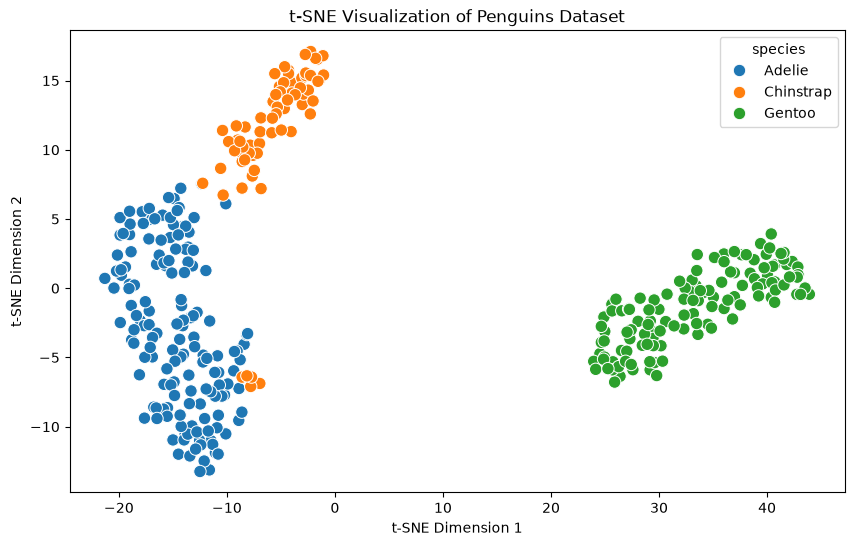

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="species",
    s=80
)

plt.title(
    "t-SNE Visualization of Penguins Dataset"
)

plt.xlabel(
    "t-SNE Dimension 1"
)

plt.ylabel(
    "t-SNE Dimension 2"
)

plt.show()